In [167]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [168]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [169]:
import joblib


In [170]:
pd.set_option('display.max_columns', None)
%matplotlib inline

In [235]:
df= pd.read_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\processed\df_clean_start.csv")
print("shape:",df.shape)
df.head()

shape: (4372, 52)


,CustomerID,Recency,Frequency,MonetaryTotal,MonetaryAvg,MonetaryStd,MonetaryMin,MonetaryMax,TotalQuantity,AvgQuantityPerTransaction,MinQuantity,MaxQuantity,CustomerTenureDays,FirstPurchaseDaysAgo,PreferredDayOfWeek,PreferredHour,PreferredMonth,WeekendPurchaseRatio,AvgDaysBetweenPurchases,UniqueProducts,UniqueDescriptions,AvgProductsPerTransaction,UniqueCountries,NegativeQuantityCount,ZeroPriceCount,CancelledTransactions,ReturnRatio,TotalTransactions,UniqueInvoices,AvgLinesPerInvoice,Age,RegistrationDate,NewsletterSubscribed,LastLoginIP,SupportTicketsCount,SatisfactionScore,RFMSegment,AgeCategory,SpendingCategory,CustomerType,FavoriteSeason,PreferredTimeOfDay,Region,LoyaltyLevel,ChurnRiskCategory,WeekendPreference,BasketSizeCategory,ProductDiversity,Gender,AccountStatus,Country,Churn
0,17850,302,35,5288.63,16.950737,13.603662,-30.60,107.25,1693,5.426282,-12,12,71,374,3,9,12,0.000000,0.221865,24,25,0.685714,1,15,0,15,0.048077,312,35,8.914286,NaN,17/07/10,Yes,59.252.219.201,1.0,4.0,Fidèles,Inconnu,VIP,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Explorateur,Unknown,Active,United Kingdom,1
1,13047,32,18,3079.10,15.709694,11.684769,-15.00,68.00,1355,6.913265,-3,32,342,374,2,13,10,0.168367,1.717949,106,106,5.888889,1,24,0,24,0.122449,196,18,10.888889,NaN,2010-10-04,Yes,77.255.247.14,3.0,4.0,Champions,Inconnu,VIP,Régulier,Automne,Midi,UK,Établi,Moyen,Semaine,Moyen,Explorateur,M,Active,United Kingdom,0
2,12583,3,18,7187.34,28.634821,23.150132,-60.84,132.80,5009,19.956175,-36,360,370,374,4,12,11,0.055777,1.456000,115,117,6.388889,1,4,0,4,0.015936,251,18,13.944444,46.0,12/09/2009,Yes,51.139.78.80,2.0,5.0,Champions,45-54,VIP,Hyperactif,Automne,Midi,Europe continentale,Ancien,Faible,Semaine,Grand,Explorateur,Unknown,Active,France,0
3,13748,96,5,948.25,33.866071,42.953119,9.36,204.00,439,15.678571,1,80,278,374,0,9,9,0.000000,10.259259,24,24,4.800000,1,0,0,0,0.000000,28,5,5.600000,32.0,28/01/10,Yes,10.212.80.124,2.0,2.0,Potentiels,25-34,High,Nouveau,Automne,Matin,UK,Établi,Critique,Inconnu,Grand,Explorateur,Unknown,Active,United Kingdom,1
4,15100,330,6,635.10,105.850000,215.986263,-131.40,350.40,58,9.666667,-12,32,43,374,2,9,12,0.000000,8.200000,1,1,0.166667,1,3,0,3,0.500000,6,6,1.000000,NaN,2009-12-10,Yes,186.34.121.80,2.0,1.0,Potentiels,Inconnu,High,Perdu,Hiver,Matin,UK,Jeune,Critique,Inconnu,Moyen,Spécialisé,M,Active,United Kingdom,1


In [428]:
# Run this to find where negatives come from

print(df['MonetaryAvg'].describe())
print(f"\nNegative values: {(df['MonetaryAvg'] < 0).sum()}")
print(f"Min value      : {df['MonetaryAvg'].min()}")

# Show the actual negative rows
print("\nNegative MonetaryAvg rows:")
print(df[df['MonetaryAvg'] < 0]['MonetaryAvg'].head(20))

count    4372.000000
mean       28.839013
std       127.323926
min     -4287.630000
25%        10.985960
50%        16.918616
75%        23.542941
max      3861.000000
Name: MonetaryAvg, dtype: float64

Negative values: 44
Min value      : -4287.63

Negative MonetaryAvg rows:
17      -8.322353
126     -3.094516
154     -5.900000
161    -49.456471
179    -20.490000
182     -1.250000
208   -238.440000
211     -2.550000
386     -7.950000
512     -7.450000
533    -14.051905
542     -7.233333
598    -30.600000
604   -152.640000
610     -2.500000
736    -35.400000
743    -10.550000
797   -113.720000
811   -102.000000
814     -4.810000
Name: MonetaryAvg, dtype: float64


In [172]:
# Colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)

Numériques: ['CustomerID', 'Recency', 'Frequency', 'MonetaryTotal', 'MonetaryAvg', 'MonetaryStd', 'MonetaryMin', 'MonetaryMax', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'Churn']


In [173]:
# Colonnes catégorielles (object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Catégorielles:", categorical_cols)

Catégorielles: ['RegistrationDate', 'NewsletterSubscribed', 'LastLoginIP', 'RFMSegment', 'AgeCategory', 'SpendingCategory', 'CustomerType', 'FavoriteSeason', 'PreferredTimeOfDay', 'Region', 'LoyaltyLevel', 'ChurnRiskCategory', 'WeekendPreference', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'AccountStatus', 'Country']


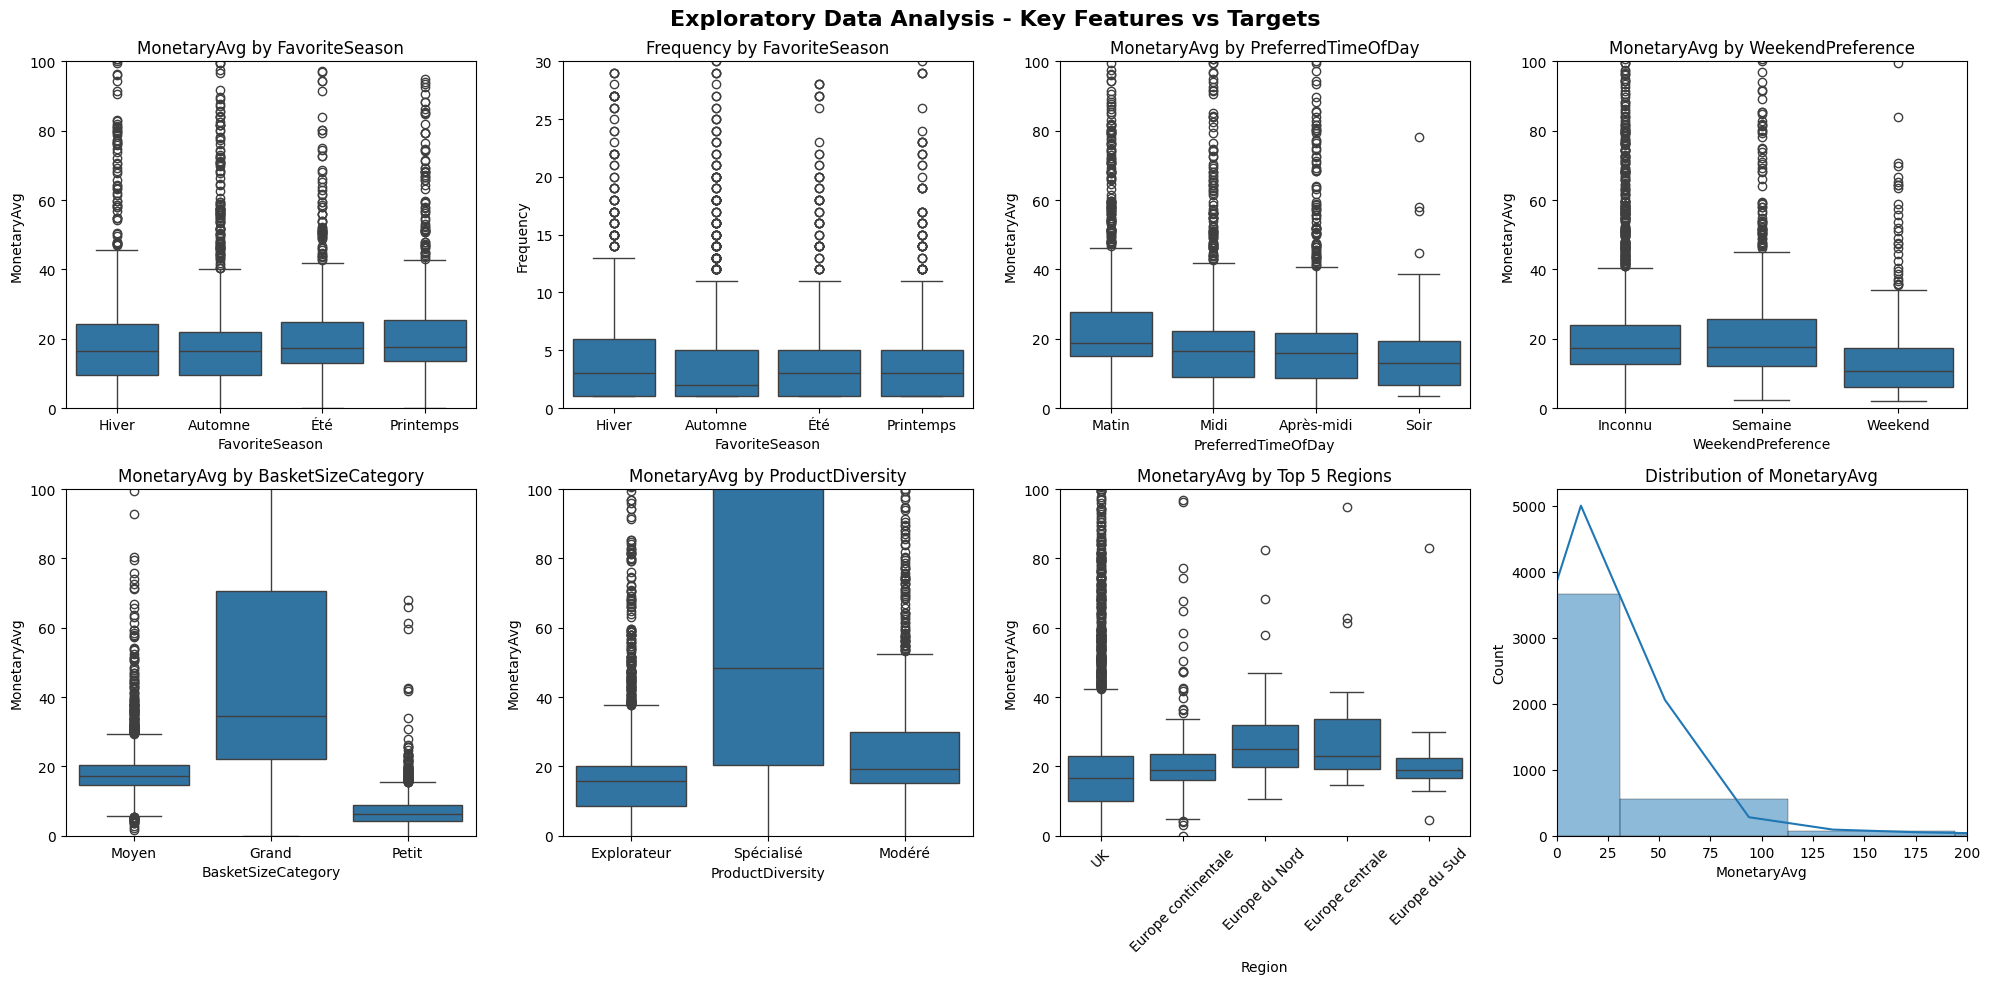

In [174]:
import matplotlib.pyplot as plt
import seaborn as sns


# Create visualizations for EDA
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Exploratory Data Analysis - Key Features vs Targets', fontsize=16, fontweight='bold')

# Plot 1: FavoriteSeason vs MonetaryAvg
sns.boxplot(data=df, x='FavoriteSeason', y='MonetaryAvg', ax=axes[0,0])
axes[0,0].set_title('MonetaryAvg by FavoriteSeason')
axes[0,0].set_ylim(0, 100)  # Limit y-axis for better visibility

# Plot 2: FavoriteSeason vs Frequency
sns.boxplot(data=df, x='FavoriteSeason', y='Frequency', ax=axes[0,1])
axes[0,1].set_title('Frequency by FavoriteSeason')
axes[0,1].set_ylim(0, 30)

# Plot 3: PreferredTimeOfDay vs MonetaryAvg
sns.boxplot(data=df, x='PreferredTimeOfDay', y='MonetaryAvg', ax=axes[0,2])
axes[0,2].set_title('MonetaryAvg by PreferredTimeOfDay')
axes[0,2].set_ylim(0, 100)

# Plot 4: WeekendPreference vs MonetaryAvg
sns.boxplot(data=df, x='WeekendPreference', y='MonetaryAvg', ax=axes[0,3])
axes[0,3].set_title('MonetaryAvg by WeekendPreference')
axes[0,3].set_ylim(0, 100)

# Plot 5: BasketSizeCategory vs MonetaryAvg
sns.boxplot(data=df, x='BasketSizeCategory', y='MonetaryAvg', ax=axes[1,0])
axes[1,0].set_title('MonetaryAvg by BasketSizeCategory')
axes[1,0].set_ylim(0, 100)

# Plot 6: ProductDiversity vs MonetaryAvg
sns.boxplot(data=df, x='ProductDiversity', y='MonetaryAvg', ax=axes[1,1])
axes[1,1].set_title('MonetaryAvg by ProductDiversity')
axes[1,1].set_ylim(0, 100)

# Plot 7: Region vs MonetaryAvg (top 5 regions)
top_regions = df['Region'].value_counts().head(5).index
df_top_regions = df[df['Region'].isin(top_regions)]
sns.boxplot(data=df_top_regions, x='Region', y='MonetaryAvg', ax=axes[1,2])
axes[1,2].set_title('MonetaryAvg by Top 5 Regions')
axes[1,2].set_ylim(0, 100)
axes[1,2].tick_params(axis='x', rotation=45)

# Plot 8: Distribution of MonetaryAvg
sns.histplot(df['MonetaryAvg'], bins=100, kde=True, ax=axes[1,3])
axes[1,3].set_title('Distribution of MonetaryAvg')
axes[1,3].set_xlim(0, 200)

plt.tight_layout()
plt.show()


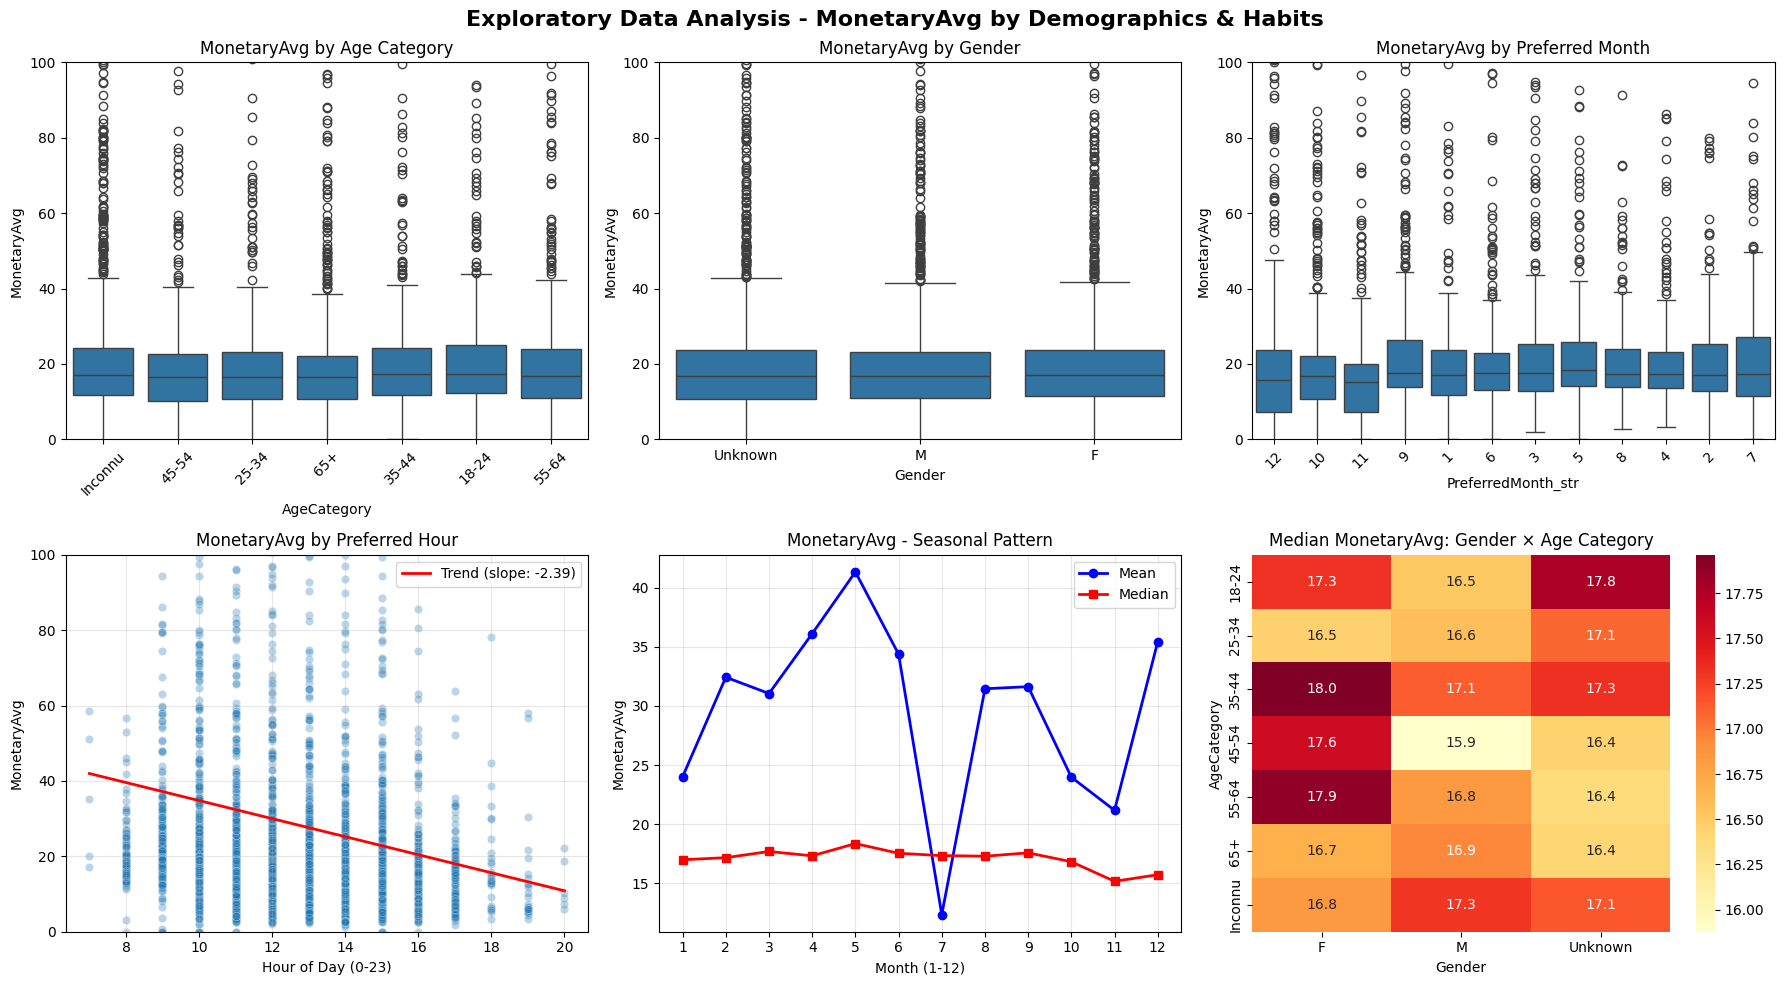

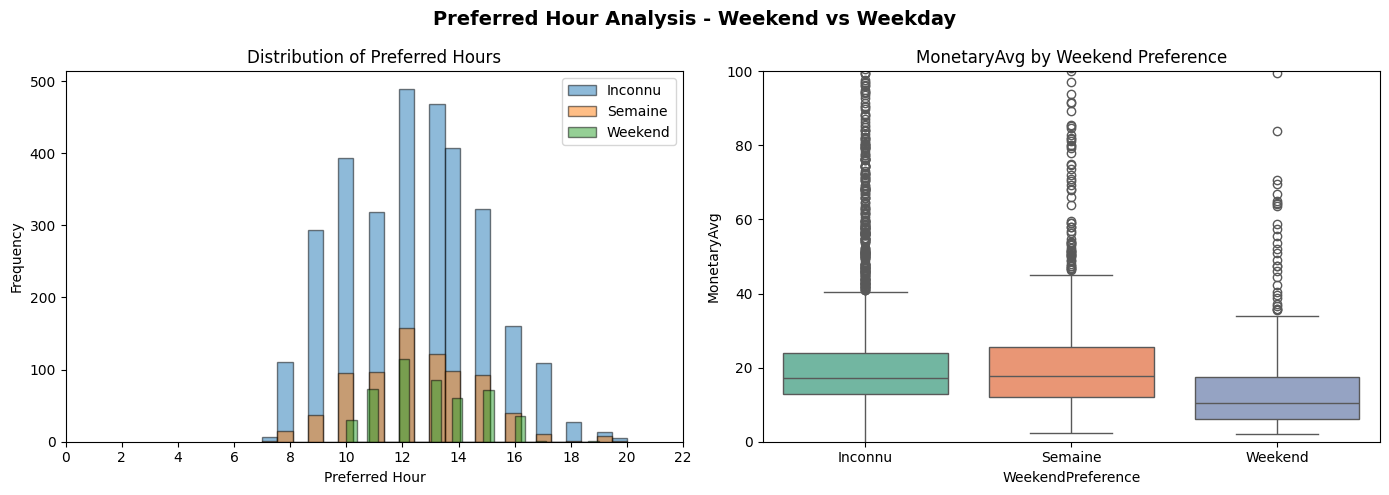


SUMMARY STATISTICS - MonetaryAvg by Demographics & Habits

1. BY AGE:
       mean  median  count
Age                       
18.0  30.78   15.63     45
19.0  22.43   18.06     57
20.0  30.65   17.39     50
21.0  23.99   18.96     46
22.0  33.88   16.93     48
...     ...     ...    ...
76.0  56.83   16.62     45
77.0  24.17   17.08     63
78.0  38.61   15.88     50
79.0  28.72   15.93     62
80.0  21.12   15.68     46

[63 rows x 3 columns]

2. BY GENDER:
          mean  median  count
Gender                       
F        29.09   17.02   1389
M        29.74   16.85   1334
Unknown  27.90   16.91   1649

3. BY PREFERRED MONTH (Top 5):
                 mean  median  count
PreferredMonth                      
5               41.34   18.36    283
4               36.12   17.32    263
12              35.42   15.72    484
6               34.38   17.54    268
2               32.43   17.16    239

4. BY PREFERRED HOUR (Peak hours):
                 mean  median  count
PreferredHour             

In [175]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create visualizations for EDA - Focus on new features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Exploratory Data Analysis - MonetaryAvg by Demographics & Habits', 
             fontsize=16, fontweight='bold')

# Plot 1: AgeCategory vs MonetaryAvg
sns.boxplot(data=df, x='AgeCategory', y='MonetaryAvg', ax=axes[0,0])
axes[0,0].set_title('MonetaryAvg by Age Category')
axes[0,0].set_ylim(0, 100)
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Gender vs MonetaryAvg
sns.boxplot(data=df, x='Gender', y='MonetaryAvg', ax=axes[0,1])
axes[0,1].set_title('MonetaryAvg by Gender')
axes[0,1].set_ylim(0, 100)

# Plot 3: PreferredMonth vs MonetaryAvg (as boxplot - categorical)
# Convert PreferredMonth to categorical for better visualization
df['PreferredMonth_str'] = df['PreferredMonth'].astype(str)
sns.boxplot(data=df, x='PreferredMonth_str', y='MonetaryAvg', ax=axes[0,2])
axes[0,2].set_title('MonetaryAvg by Preferred Month')
axes[0,2].set_ylim(0, 100)
axes[0,2].tick_params(axis='x', rotation=45)

# Plot 4: PreferredHour vs MonetaryAvg (scatter plot + trend line)
sns.scatterplot(data=df, x='PreferredHour', y='MonetaryAvg', alpha=0.3, ax=axes[1,0])
# Add trend line
z = np.polyfit(df['PreferredHour'], df['MonetaryAvg'], 1)
p = np.poly1d(z)
axes[1,0].plot(df['PreferredHour'].sort_values(), 
               p(df['PreferredHour'].sort_values()), 
               "r-", linewidth=2, label=f'Trend (slope: {z[0]:.2f})')
axes[1,0].set_title('MonetaryAvg by Preferred Hour')
axes[1,0].set_xlabel('Hour of Day (0-23)')
axes[1,0].set_ylabel('MonetaryAvg')
axes[1,0].set_ylim(0, 100)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 5: PreferredMonth as line chart (shows seasonal pattern)
monthly_avg = df.groupby('PreferredMonth')['MonetaryAvg'].agg(['mean', 'median', 'count']).reset_index()
axes[1,1].plot(monthly_avg['PreferredMonth'], monthly_avg['mean'], 'b-o', label='Mean', linewidth=2, markersize=6)
axes[1,1].plot(monthly_avg['PreferredMonth'], monthly_avg['median'], 'r-s', label='Median', linewidth=2, markersize=6)
axes[1,1].set_title('MonetaryAvg - Seasonal Pattern')
axes[1,1].set_xlabel('Month (1-12)')
axes[1,1].set_ylabel('MonetaryAvg')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xticks(range(1, 13))

# Plot 6: Gender + AgeCategory combined (heatmap)
pivot_table = df.pivot_table(values='MonetaryAvg', 
                             index='AgeCategory', 
                             columns='Gender', 
                             aggfunc='median')
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[1,2])
axes[1,2].set_title('Median MonetaryAvg: Gender × Age Category')

plt.tight_layout()
plt.show()

# Additional analysis: PreferredHour by WeekendPreference
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Preferred Hour Analysis - Weekend vs Weekday', fontsize=14, fontweight='bold')

# Plot: PreferredHour distribution by WeekendPreference
for preference in df['WeekendPreference'].unique():
    subset = df[df['WeekendPreference'] == preference]
    axes[0].hist(subset['PreferredHour'], bins=24, alpha=0.5, label=preference, edgecolor='black')
axes[0].set_xlabel('Preferred Hour')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Preferred Hours')
axes[0].legend()
axes[0].set_xticks(range(0, 24, 2))

# Boxplot: PreferredHour vs MonetaryAvg by WeekendPreference
sns.boxplot(data=df, x='WeekendPreference', y='MonetaryAvg', hue='WeekendPreference', 
            ax=axes[1], palette='Set2')
axes[1].set_title('MonetaryAvg by Weekend Preference')
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("SUMMARY STATISTICS - MonetaryAvg by Demographics & Habits")
print("="*60)

print("\n1. BY AGE:")
print(df.groupby('Age')['MonetaryAvg'].agg(['mean', 'median', 'count']).round(2))

print("\n2. BY GENDER:")
print(df.groupby('Gender')['MonetaryAvg'].agg(['mean', 'median', 'count']).round(2))

print("\n3. BY PREFERRED MONTH (Top 5):")
monthly_stats = df.groupby('PreferredMonth')['MonetaryAvg'].agg(['mean', 'median', 'count']).round(2)
print(monthly_stats.sort_values('mean', ascending=False).head())

print("\n4. BY PREFERRED HOUR (Peak hours):")
hourly_stats = df.groupby('PreferredHour')['MonetaryAvg'].agg(['mean', 'median', 'count']).round(2)
print(hourly_stats.sort_values('mean', ascending=False).head(10))

print("\n5. GENDER × AGE CATEGORY (Median MonetaryAvg):")
print(df.pivot_table(values='MonetaryAvg', index='AgeCategory', columns='Gender', aggfunc='median').round(2))

#Interpretation:
low variation : fav season,preferred time of the day, weekend pref
keeping: basket size category,product diversity,region

In [236]:
drop_target_related = [
    'MonetaryTotal',      # Sum of MonetaryAvg
    'MonetaryStd',        # Calculated from MonetaryAvg
    'MonetaryMin',        # Directly related
    'MonetaryMax',        # Directly related
    'SpendingCategory'    # Usually derived from MonetaryAvg
]

In [237]:
df=df.drop(columns=drop_target_related)
df.shape

(4372, 47)

In [238]:
irrelevent = [
    'CustomerID',
    'RFMSegment',
    'CustomerType',
    'RegistrationDate',
    'LastLoginIP',
    'FavoriteSeason',
    'WeekendPreference',
    'PreferredTimeOfDay',
    'AccountStatus', #result
    'Recency',
    'Churn',
    'ChurnRiskCategory', #derived
    
    
]

In [239]:
df=df.drop(columns=irrelevent)



In [240]:
df.shape

(4372, 35)

In [181]:
df['LoyaltyLevel']

0         Jeune
1        Établi
2        Ancien
3        Établi
4         Jeune
         ...   
4367    Nouveau
4368    Nouveau
4369    Nouveau
4370    Nouveau
4371    Nouveau
Name: LoyaltyLevel, Length: 4372, dtype: object

In [182]:
# Colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)
# Colonnes catégorielles (object)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Catégorielles:", categorical_cols)

Numériques: ['Frequency', 'MonetaryAvg', 'TotalQuantity', 'AvgQuantityPerTransaction', 'MinQuantity', 'MaxQuantity', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'UniqueCountries', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore']
Catégorielles: ['NewsletterSubscribed', 'AgeCategory', 'Region', 'LoyaltyLevel', 'BasketSizeCategory', 'ProductDiversity', 'Gender', 'Country', 'PreferredMonth_str']


In [241]:
drop=['MinQuantity', 'MaxQuantity', 'NewsletterSubscribed']
df=df.drop(columns=drop)




In [242]:
df=df.drop(columns='UniqueCountries')


In [243]:
df=df.drop(columns='AgeCategory')


In [244]:
df=df.drop(columns='TotalQuantity')


In [245]:
df.shape

(4372, 29)

In [246]:
# Vue d'ensemble
print("Shape:", df.shape)
print("\nValeurs manquantes :")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDoublons :", df.duplicated().sum())
print("\nTypes :")
print(df.dtypes.value_counts())

Shape: (4372, 29)

Valeurs manquantes :
AvgDaysBetweenPurchases      79
Age                        1311
dtype: int64

Doublons : 0

Types :
int64      13
float64    10
object      6
Name: count, dtype: int64


🔢 Étape 2 — Conversion des colonnes numériques stockées en object-->numerique




In [247]:
cols_to_convert = [
    'MonetaryAvg',
    'AvgQuantityPerTransaction', 'AvgDaysBetweenPurchases',
    'AvgProductsPerTransaction', 'AvgLinesPerInvoice'
]

for col in cols_to_convert:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Conversion OK")
print(df[cols_to_convert].dtypes)

Conversion OK
MonetaryAvg                  float64
AvgQuantityPerTransaction    float64
AvgDaysBetweenPurchases      float64
AvgProductsPerTransaction    float64
AvgLinesPerInvoice           float64
dtype: object


In [248]:
print(df['ReturnRatio'].dtype)        # → float64
print(df['WeekendPurchaseRatio'].dtype) # → float64

float64
float64


🚨 Étape 3 — Correction des valeurs aberrantes par NaN


In [249]:
# SupportTicketsCount : -1 et 999 sont des codes erreur
df['SupportTicketsCount'] = df['SupportTicketsCount'].replace([-1, 999], np.nan)

# SatisfactionScore : -1, 0, 99 sont invalides (échelle 1-5)
df['SatisfactionScore'] = df['SatisfactionScore'].apply(
    lambda x: np.nan if x in [-1, 0, 99] else x
)

print("Aberrantes corrigées")
print(df[['SupportTicketsCount', 'SatisfactionScore']].describe())

Aberrantes corrigées
       SupportTicketsCount  SatisfactionScore
count          4242.000000        4023.000000
mean              1.967468           3.013671
std               1.402116           1.431882
min               0.000000           1.000000
25%               1.000000           2.000000
50%               2.000000           3.000000
75%               3.000000           4.000000
max               9.000000           5.000000


🌐 Étape 5 — Feature engineering sur LastLoginIP


In [191]:
df['Country'] 

0       United Kingdom
1       United Kingdom
2               France
3       United Kingdom
4       United Kingdom
             ...      
4367    United Kingdom
4368    United Kingdom
4369    United Kingdom
4370    United Kingdom
4371           Germany
Name: Country, Length: 4372, dtype: object

🗑️ Étape 6 — Suppression des colonnes inutiles


✅ 1. Trop de valeurs manquantes (>50%)

In [192]:
missing_ratio = df.isna().mean()

# features with >50% missing
high_missing = missing_ratio[missing_ratio > 0.5]

print(high_missing)

Series([], dtype: float64)


⚙️ Étape 7 — Feature engineering


In [193]:
df.columns


Index(['Frequency', 'MonetaryAvg', 'TotalQuantity',
       'AvgQuantityPerTransaction', 'CustomerTenureDays',
       'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour',
       'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases',
       'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction',
       'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions',
       'ReturnRatio', 'TotalTransactions', 'UniqueInvoices',
       'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore',
       'Region', 'LoyaltyLevel', 'BasketSizeCategory', 'ProductDiversity',
       'Gender', 'Country', 'PreferredMonth_str'],
      dtype='object')

In [250]:
# Overall problem ratio (returns + cancellations + negatives)
df['ProblemRatio'] = (
    df['ReturnRatio'] +
    df['CancelledTransactions'] / (df['TotalTransactions'] + 1) +
    df['NegativeQuantityCount'] / (df['TotalTransactions'] + 1)
)

# Zero price anomaly rate
df['ZeroPriceRatio'] = df['ZeroPriceCount'] / (df['TotalTransactions'] + 1)

# Support burden score
df['SupportBurden'] = df['SupportTicketsCount'] / (df['CustomerTenureDays'] + 1)

In [251]:
# Basket complexity — how varied is each transaction?
df['BasketComplexity'] = df['UniqueProducts'] / (df['TotalTransactions'] + 1)

# Product exploration ratio
df['ExplorationRatio'] = df['UniqueDescriptions'] / (df['UniqueProducts'] + 1)

# Lines per product (how detailed the basket is)
df['LinesPerProduct'] = df['AvgLinesPerInvoice'] / (df['AvgProductsPerTransaction'] + 1)

In [252]:
print("Shape final :", df.shape)
print("\nValeurs manquantes restantes :")
missing = df.isnull().sum()
print(missing[missing > 0])

print("\nTypes finaux :")
print(df.dtypes.value_counts())



Shape final : (4372, 35)

Valeurs manquantes restantes :
AvgDaysBetweenPurchases      79
Age                        1311
SupportTicketsCount         130
SatisfactionScore           349
SupportBurden               130
dtype: int64

Types finaux :
float64    16
int64      13
object      6
Name: count, dtype: int64


In [253]:
# Colonnes numériques
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numériques:", numeric_cols)

Numériques: ['Frequency', 'MonetaryAvg', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'ProblemRatio', 'ZeroPriceRatio', 'SupportBurden', 'BasketComplexity', 'ExplorationRatio', 'LinesPerProduct']


In [254]:
df.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\processed\df_processed_linear.csv", index=False)

In [200]:
print('SpendPerQuantity' in df.columns)  # → True


False


Sauvegarder data/processed/df_processed

prochaines etapes:
diviser en test/train
imputation,scaler ,encodage,equilibrage,

In [659]:
df = pd.read_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\processed\df_processed_linear.csv")
print("Shape:", df.shape)

Shape: (4372, 35)


## Splitting

In [660]:
# ── 2. Define target & features ────────────────────────────────────────────────
TARGET = 'MonetaryAvg'  

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y value counts:\n", y.value_counts())

X shape: (4372, 34)
y value counts:
 MonetaryAvg
0.000000      8
76.320000     4
15.000000     4
179.000000    4
25.500000     3
             ..
16.407500     1
19.083333     1
180.000000    1
18.949167     1
72.306562     1
Name: count, Length: 4330, dtype: int64


In [661]:
# Soft cap at 1st and 99th percentile
# Keeps negatives but reduces extreme influence
p1  = df['MonetaryAvg'].quantile(0.01)
p99 = df['MonetaryAvg'].quantile(0.99)

print(f"1st  percentile: {p1:.2f}")
print(f"99th percentile: {p99:.2f}")

y = y.clip(lower=p1, upper=p99)

print(f"\nAfter capping:")
print(f"Min : {y.min():.2f}")
print(f"Max : {y.max():.2f}")
print(f"Mean: {y.mean():.2f}")

1st  percentile: -0.00
99th percentile: 311.86

After capping:
Min : -0.00
Max : 311.86
Mean: 26.74


In [662]:
# ── 3. Train / Test split (stratified) ────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\ny_test  distribution:\n{y_test.value_counts(normalize=True).round(3)}")

Train: (3497, 34)  |  Test: (875, 34)

y_train distribution:
MonetaryAvg
-2.341561e-17    0.010
 3.118580e+02    0.009
 0.000000e+00    0.002
 1.790000e+02    0.001
 7.632000e+01    0.001
                 ...  
 1.493300e+01    0.000
 8.971433e+00    0.000
 2.704833e+01    0.000
 1.718250e+01    0.000
 2.168129e+01    0.000
Name: proportion, Length: 3403, dtype: float64

y_test  distribution:
MonetaryAvg
 3.118580e+02    0.014
-2.341561e-17    0.009
 2.550000e+01    0.002
 1.310933e+01    0.001
 9.509750e+00    0.001
                 ...  
 1.511931e+01    0.001
 1.788889e+01    0.001
 8.534802e+01    0.001
 2.494600e+01    0.001
 1.066000e+02    0.001
Name: proportion, Length: 856, dtype: float64


In [663]:
# ── 4. Save splits ─────────────────────────────────────────────────────────────
import os
output_dir = r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others"
os.makedirs(output_dir, exist_ok=True)

X_train.to_csv(os.path.join(output_dir, "X_train.csv"), index=False)
X_test.to_csv(os.path.join(output_dir,  "X_test.csv"),  index=False)
y_train.to_csv(os.path.join(output_dir, "y_train.csv"), index=False)
y_test.to_csv(os.path.join(output_dir,  "y_test.csv"),  index=False)

print("Splits saved ✓")

Splits saved ✓


imputation

Median for skewed features — you have negative values and outliers so median is safer than mean

In [664]:
train_num = X_train.select_dtypes(include="number").columns.tolist()
print(train_num)

['Frequency', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredHour', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'UniqueDescriptions', 'AvgProductsPerTransaction', 'NegativeQuantityCount', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'ProblemRatio', 'ZeroPriceRatio', 'SupportBurden', 'BasketComplexity', 'ExplorationRatio', 'LinesPerProduct']


In [665]:
cols_with_nan = X_train.columns[X_train.isnull().any()]
print(cols_with_nan)
X_train[cols_with_nan]

Index(['AvgDaysBetweenPurchases', 'Age', 'SupportTicketsCount',
       'SatisfactionScore', 'SupportBurden'],
      dtype='object')


,AvgDaysBetweenPurchases,Age,SupportTicketsCount,SatisfactionScore,SupportBurden
2575,1.818182,37.0,0.0,3.0,0.000000
680,0.000000,69.0,3.0,3.0,3.000000
2834,0.000000,77.0,5.0,5.0,5.000000
203,20.785714,49.0,3.0,2.0,0.010274
2529,5.400000,50.0,2.0,3.0,0.071429
...,...,...,...,...,...
3444,0.347826,71.0,0.0,3.0,0.000000
466,12.814815,NaN,1.0,4.0,0.002849
3092,0.875776,NaN,3.0,2.0,0.020979
3772,1.447368,NaN,3.0,4.0,0.051724


In [666]:
# ── 2. Median imputation on specific columns ───────────────────────────────────
cols_median = ['AvgDaysBetweenPurchases', 'SupportTicketsCount',
       'SatisfactionScore', 'SupportBurden']

imputer_median = SimpleImputer(strategy='median')

# Fit on X_train ONLY, transform both
X_train[cols_median] = imputer_median.fit_transform(X_train[cols_median])
X_test[cols_median]  = imputer_median.transform(X_test[cols_median])

print("Medians learned from X_train:")
for col, med in zip(cols_median, imputer_median.statistics_):
    print(f"  {col}: {med}")

Medians learned from X_train:
  AvgDaysBetweenPurchases: 1.147540983606557
  SupportTicketsCount: 2.0
  SatisfactionScore: 3.0
  SupportBurden: 0.01476923636231435


In [667]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd
cols_knn = ['Age', 'Frequency', 'CustomerTenureDays']


scaler_knn = StandardScaler()

X_train_scaled = scaler_knn.fit_transform(X_train[cols_knn])
X_test_scaled  = scaler_knn.transform(X_test[cols_knn])
imputer = KNNImputer(n_neighbors=5)

X_train_imputed = imputer.fit_transform(X_train_scaled)
X_test_imputed  = imputer.transform(X_test_scaled)

X_train[cols_knn] = pd.DataFrame(
    scaler_knn.inverse_transform(X_train_imputed),
    columns=cols_knn,
    index=X_train.index
)

X_test[cols_knn] = pd.DataFrame(
    scaler_knn.inverse_transform(X_test_imputed),
    columns=cols_knn,
    index=X_test.index
)
print("Missing Age after imputation:")
print(X_train['Age'].isnull().sum(), X_test['Age'].isnull().sum())


Missing Age after imputation:
0 0


In [668]:
X_train[cols_with_nan]

,AvgDaysBetweenPurchases,Age,SupportTicketsCount,SatisfactionScore,SupportBurden
2575,1.818182,37.0,0.0,3.0,0.000000
680,0.000000,69.0,3.0,3.0,3.000000
2834,0.000000,77.0,5.0,5.0,5.000000
203,20.785714,49.0,3.0,2.0,0.010274
2529,5.400000,50.0,2.0,3.0,0.071429
...,...,...,...,...,...
3444,0.347826,71.0,0.0,3.0,0.000000
466,12.814815,45.6,1.0,4.0,0.002849
3092,0.875776,53.0,3.0,2.0,0.020979
3772,1.447368,46.0,3.0,4.0,0.051724


In [669]:
os.makedirs(r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear", exist_ok=True)

joblib.dump(imputer_median, 
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\imputer_median.pkl")
joblib.dump(imputer, 
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\imputer_knn.pkl")
joblib.dump(scaler_knn, 
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\scaler_knn.pkl")
X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_test.csv",  index=False)

## Correlation

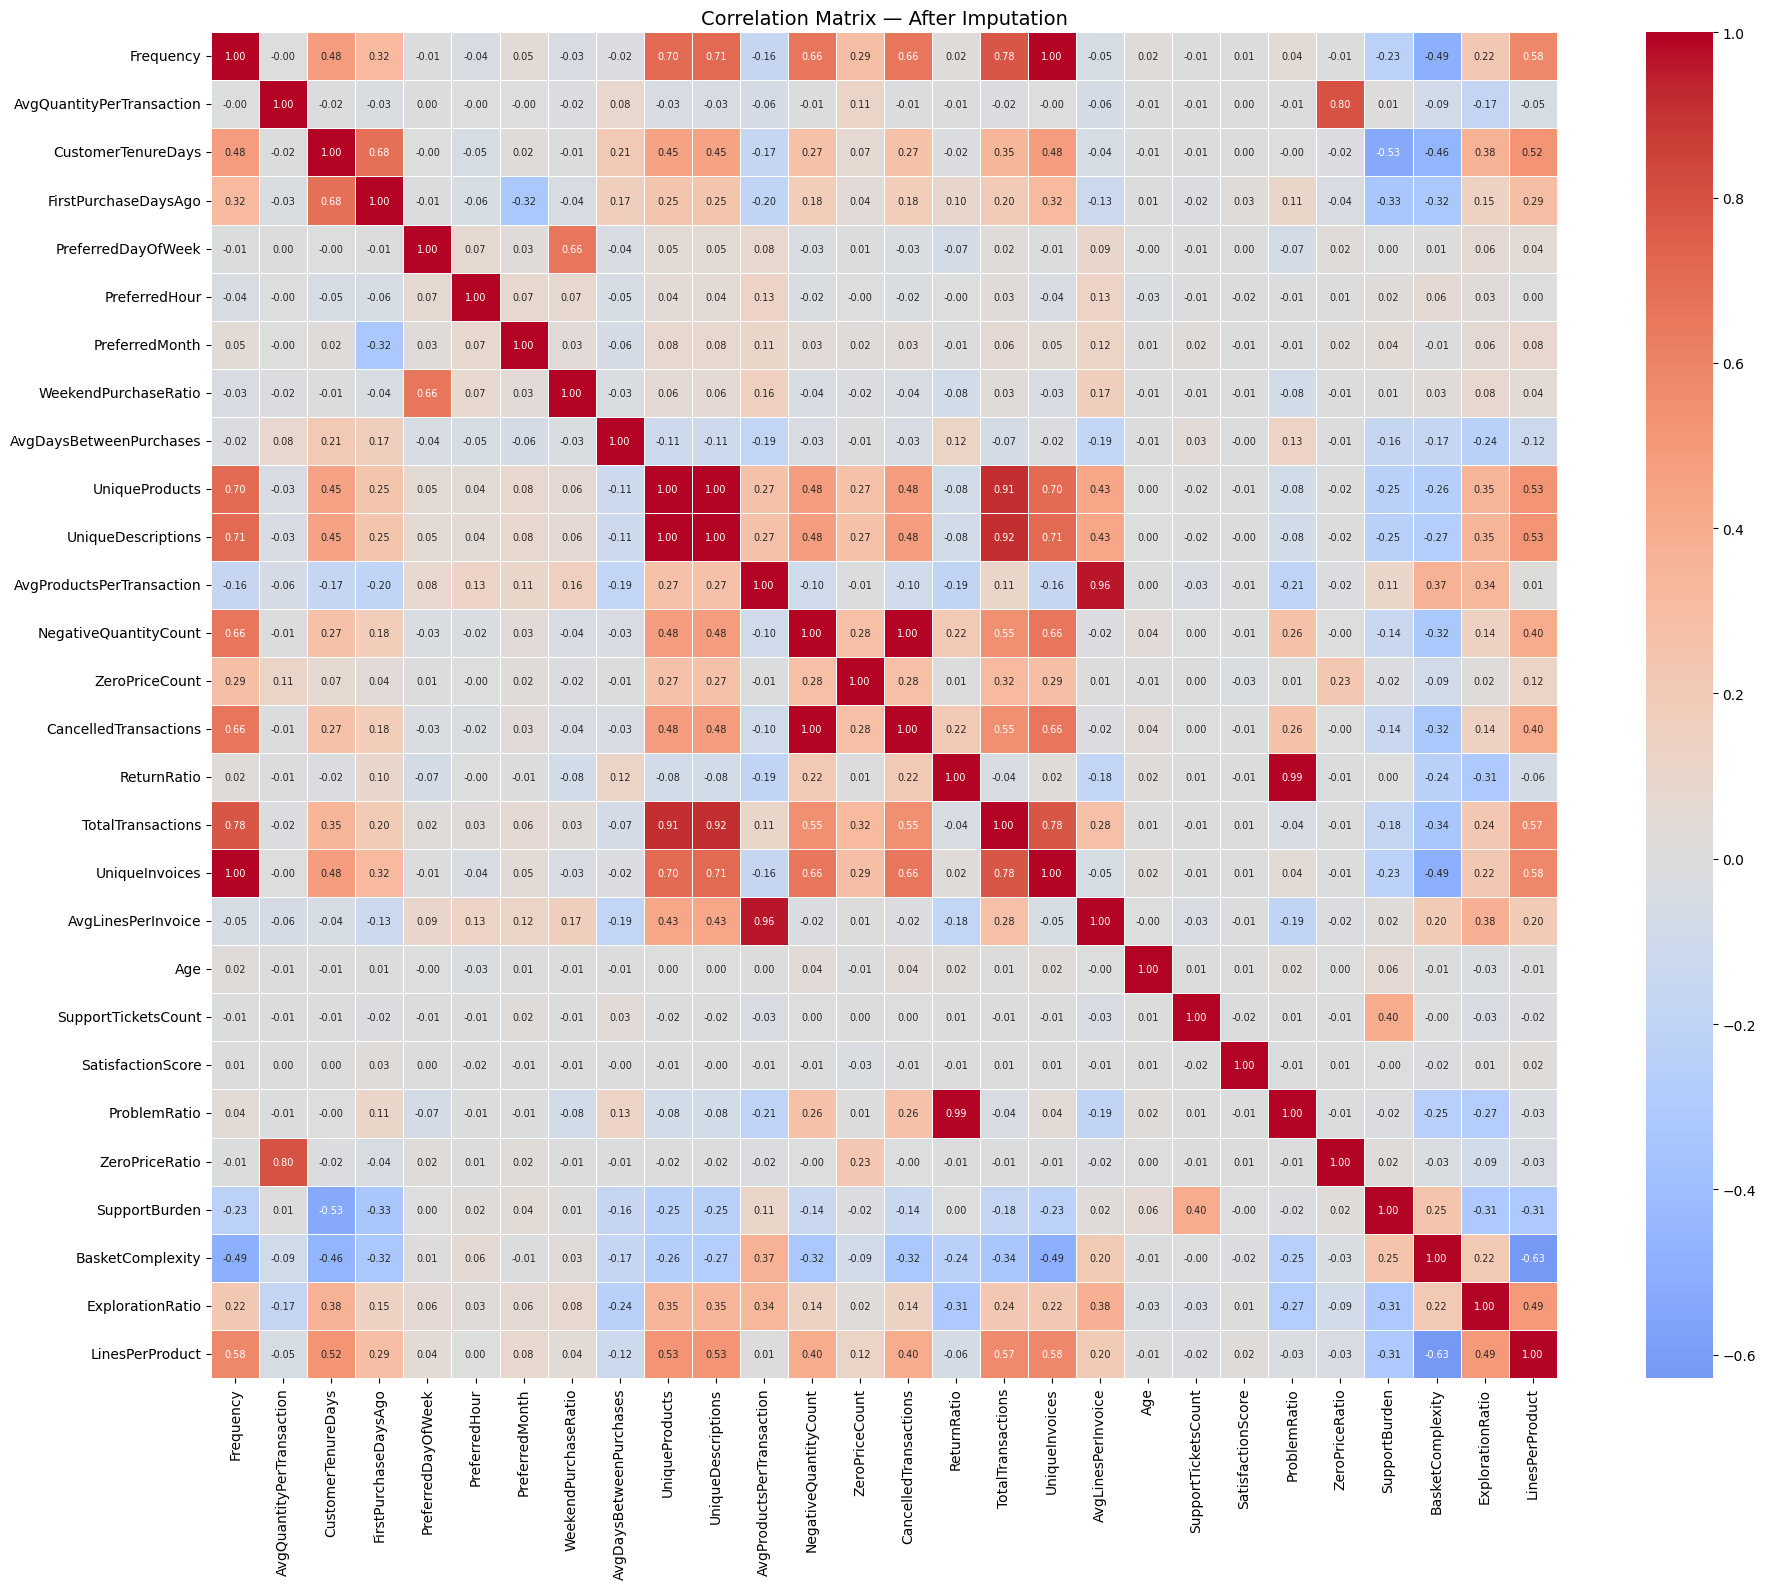

In [670]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
col = X_train.select_dtypes(include="number").columns.tolist()


# Use your numerical features after imputation
# Before encoding and scaling
corr_matrix = X_train[col].corr()

# Plot heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 7}
)
plt.title('Correlation Matrix — After Imputation', fontsize=14)
plt.tight_layout()
plt.show()

In [671]:
# Find pairs above threshold
def get_correlated_pairs(corr_matrix, threshold=0.8):
    corr_pairs = []
    
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i):  # lower triangle only
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > threshold:
                corr_pairs.append({
                    'Feature_1'  : cols[i],
                    'Feature_2'  : cols[j],
                    'Correlation': round(corr_val, 4),
                    'Abs_Corr'   : round(abs(corr_val), 4)
                })
    
    result = pd.DataFrame(corr_pairs)
    if len(result) > 0:
        result = result.sort_values('Abs_Corr', ascending=False)
    return result

# Test different thresholds
for threshold in [0.9, 0.8, 0.7]:
    pairs = get_correlated_pairs(corr_matrix, threshold)
    print(f"Threshold {threshold}: {len(pairs)} correlated pairs")
    # Show all pairs above 0.8
high_corr = get_correlated_pairs(corr_matrix, threshold=0.8)

print("=== HIGHLY CORRELATED PAIRS (|r| > 0.8) ===")
print(high_corr.to_string(index=False))

Threshold 0.9: 7 correlated pairs
Threshold 0.8: 8 correlated pairs
Threshold 0.7: 14 correlated pairs
=== HIGHLY CORRELATED PAIRS (|r| > 0.8) ===
            Feature_1                 Feature_2  Correlation  Abs_Corr
CancelledTransactions     NegativeQuantityCount       1.0000    1.0000
       UniqueInvoices                 Frequency       1.0000    1.0000
   UniqueDescriptions            UniqueProducts       0.9999    0.9999
         ProblemRatio               ReturnRatio       0.9878    0.9878
   AvgLinesPerInvoice AvgProductsPerTransaction       0.9626    0.9626
    TotalTransactions        UniqueDescriptions       0.9165    0.9165
    TotalTransactions            UniqueProducts       0.9146    0.9146
       ZeroPriceRatio AvgQuantityPerTransaction       0.8014    0.8014


In [672]:
drop=['NegativeQuantityCount','UniqueInvoices','UniqueDescriptions',  'ProblemRatio', 'AvgLinesPerInvoice', 'TotalTransactions']     

In [673]:
X_train=X_train.drop(columns=drop)
X_test=X_test.drop(columns=drop)

In [674]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

def calculate_vif(X):
    """
    Calculate VIF for all numerical features.
    X must have NO NaN, NO object columns, NO inf.
    """
    # Only numerical columns
    X_num = X_train.select_dtypes(include=[np.number]).copy()
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_num.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_num.values, i)
        for i in range(X_num.shape[1])
    ]
    
    vif_data = vif_data.sort_values('VIF', ascending=False)
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda x: '❌ Drop'     if x > 10
             else '🟡 Check'    if x > 5
             else '✅ Keep'
    )
    return vif_data

# Run on X_train ONLY (after imputation, before scaling)
vif_results = calculate_vif(X_train)
print("=== VIF RESULTS ===")
print(vif_results.to_string(index=False))

=== VIF RESULTS ===
                  Feature        VIF  Status
         ExplorationRatio 439.503323  ❌ Drop
         BasketComplexity 156.472184  ❌ Drop
          LinesPerProduct  76.055080  ❌ Drop
            PreferredHour  28.185924  ❌ Drop
     FirstPurchaseDaysAgo  11.138452  ❌ Drop
                      Age  10.315759  ❌ Drop
       CustomerTenureDays   8.412007 🟡 Check
           PreferredMonth   7.280266 🟡 Check
        SatisfactionScore   5.678865 🟡 Check
                Frequency   5.174966 🟡 Check
       PreferredDayOfWeek   5.114631 🟡 Check
           UniqueProducts   5.105654 🟡 Check
      SupportTicketsCount   3.930531  ✅ Keep
AvgProductsPerTransaction   3.789170  ✅ Keep
           ZeroPriceRatio   3.053816  ✅ Keep
AvgQuantityPerTransaction   2.968208  ✅ Keep
            SupportBurden   2.472522  ✅ Keep
     WeekendPurchaseRatio   2.225256  ✅ Keep
    CancelledTransactions   2.132560  ✅ Keep
              ReturnRatio   1.353198  ✅ Keep
  AvgDaysBetweenPurchases   1.31321

In [675]:
X_train=X_train.drop(columns='ExplorationRatio')

X_test=X_test.drop(columns='ExplorationRatio')




In [676]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

def calculate_vif(X):
    """
    Calculate VIF for all numerical features.
    X must have NO NaN, NO object columns, NO inf.
    """
    # Only numerical columns
    X_num = X_train.select_dtypes(include=[np.number]).copy()
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_num.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_num.values, i)
        for i in range(X_num.shape[1])
    ]
    
    vif_data = vif_data.sort_values('VIF', ascending=False)
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda x: '❌ Drop'     if x > 10
             else '🟡 Check'    if x > 5
             else '✅ Keep'
    )
    return vif_data

# Run on X_train ONLY (after imputation, before scaling)
vif_results = calculate_vif(X_train)
print("=== VIF RESULTS ===")
print(vif_results.to_string(index=False))

=== VIF RESULTS ===
                  Feature       VIF  Status
            PreferredHour 27.194685  ❌ Drop
         BasketComplexity 24.663976  ❌ Drop
          LinesPerProduct 18.496840  ❌ Drop
     FirstPurchaseDaysAgo 11.125708  ❌ Drop
                      Age 10.146690  ❌ Drop
       CustomerTenureDays  7.412368 🟡 Check
           PreferredMonth  7.278945 🟡 Check
        SatisfactionScore  5.619018 🟡 Check
       PreferredDayOfWeek  5.104774 🟡 Check
                Frequency  5.070211 🟡 Check
           UniqueProducts  4.887779  ✅ Keep
      SupportTicketsCount  3.863029  ✅ Keep
AvgProductsPerTransaction  3.776527  ✅ Keep
           ZeroPriceRatio  3.051502  ✅ Keep
AvgQuantityPerTransaction  2.966437  ✅ Keep
            SupportBurden  2.374663  ✅ Keep
     WeekendPurchaseRatio  2.225252  ✅ Keep
    CancelledTransactions  2.128946  ✅ Keep
              ReturnRatio  1.339774  ✅ Keep
  AvgDaysBetweenPurchases  1.312291  ✅ Keep
           ZeroPriceCount  1.247176  ✅ Keep


In [677]:
X_train=X_train.drop(columns='PreferredHour')
X_test=X_test.drop(columns='PreferredHour')



In [678]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

def calculate_vif(X):
    """
    Calculate VIF for all numerical features.
    X must have NO NaN, NO object columns, NO inf.
    """
    # Only numerical columns
    X_num = X_train.select_dtypes(include=[np.number]).copy()
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_num.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_num.values, i)
        for i in range(X_num.shape[1])
    ]
    
    vif_data = vif_data.sort_values('VIF', ascending=False)
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda x: '❌ Drop'     if x > 10
             else '🟡 Check'    if x > 5
             else '✅ Keep'
    )
    return vif_data

# Run on X_train ONLY (after imputation, before scaling)
vif_results = calculate_vif(X_train)
print("=== VIF RESULTS ===")
print(vif_results.to_string(index=False))

=== VIF RESULTS ===
                  Feature       VIF  Status
         BasketComplexity 18.248478  ❌ Drop
          LinesPerProduct 15.777922  ❌ Drop
     FirstPurchaseDaysAgo 11.021822  ❌ Drop
                      Age 10.090661  ❌ Drop
       CustomerTenureDays  7.379511 🟡 Check
           PreferredMonth  7.137690 🟡 Check
        SatisfactionScore  5.605740 🟡 Check
       PreferredDayOfWeek  5.083414 🟡 Check
                Frequency  5.069264 🟡 Check
           UniqueProducts  4.885375  ✅ Keep
      SupportTicketsCount  3.859942  ✅ Keep
AvgProductsPerTransaction  3.773877  ✅ Keep
           ZeroPriceRatio  3.048541  ✅ Keep
AvgQuantityPerTransaction  2.953516  ✅ Keep
            SupportBurden  2.374185  ✅ Keep
     WeekendPurchaseRatio  2.225216  ✅ Keep
    CancelledTransactions  2.124055  ✅ Keep
              ReturnRatio  1.313256  ✅ Keep
  AvgDaysBetweenPurchases  1.302916  ✅ Keep
           ZeroPriceCount  1.247163  ✅ Keep


In [679]:
X_train=X_train.drop(columns='BasketComplexity')
X_test=X_test.drop(columns='BasketComplexity')



In [680]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

def calculate_vif(X):
    """
    Calculate VIF for all numerical features.
    X must have NO NaN, NO object columns, NO inf.
    """
    # Only numerical columns
    X_num = X_train.select_dtypes(include=[np.number]).copy()
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_num.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_num.values, i)
        for i in range(X_num.shape[1])
    ]
    
    vif_data = vif_data.sort_values('VIF', ascending=False)
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda x: '❌ Drop'     if x > 10
             else '🟡 Check'    if x > 5
             else '✅ Keep'
    )
    return vif_data

# Run on X_train ONLY (after imputation, before scaling)
vif_results = calculate_vif(X_train)
print("=== VIF RESULTS ===")
print(vif_results.to_string(index=False))

=== VIF RESULTS ===
                  Feature       VIF  Status
          LinesPerProduct 15.714633  ❌ Drop
     FirstPurchaseDaysAgo  9.299750 🟡 Check
                      Age  8.731072 🟡 Check
       CustomerTenureDays  6.782250 🟡 Check
           PreferredMonth  6.098929 🟡 Check
        SatisfactionScore  5.288059 🟡 Check
                Frequency  4.980410  ✅ Keep
       PreferredDayOfWeek  4.966651  ✅ Keep
           UniqueProducts  4.877297  ✅ Keep
      SupportTicketsCount  3.759966  ✅ Keep
AvgProductsPerTransaction  3.444654  ✅ Keep
           ZeroPriceRatio  3.047836  ✅ Keep
AvgQuantityPerTransaction  2.949432  ✅ Keep
            SupportBurden  2.374183  ✅ Keep
     WeekendPurchaseRatio  2.208280  ✅ Keep
    CancelledTransactions  2.124053  ✅ Keep
  AvgDaysBetweenPurchases  1.302025  ✅ Keep
              ReturnRatio  1.281861  ✅ Keep
           ZeroPriceCount  1.246065  ✅ Keep


In [681]:
X_train=X_train.drop(columns='LinesPerProduct')
X_test=X_test.drop(columns='LinesPerProduct')



In [682]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

def calculate_vif(X):
    """
    Calculate VIF for all numerical features.
    X must have NO NaN, NO object columns, NO inf.
    """
    # Only numerical columns
    X_num = X_train.select_dtypes(include=[np.number]).copy()
    
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X_num.columns
    vif_data['VIF'] = [
        variance_inflation_factor(X_num.values, i)
        for i in range(X_num.shape[1])
    ]
    
    vif_data = vif_data.sort_values('VIF', ascending=False)
    vif_data['Status'] = vif_data['VIF'].apply(
        lambda x: '❌ Drop'     if x > 10
             else '🟡 Check'    if x > 5
             else '✅ Keep'
    )
    return vif_data

# Run on X_train ONLY (after imputation, before scaling)
vif_results = calculate_vif(X_train)
print("=== VIF RESULTS ===")
print(vif_results.to_string(index=False))

=== VIF RESULTS ===
                  Feature      VIF  Status
     FirstPurchaseDaysAgo 8.832369 🟡 Check
                      Age 8.032049 🟡 Check
       CustomerTenureDays 6.651973 🟡 Check
           PreferredMonth 5.480443 🟡 Check
        SatisfactionScore 5.034936 🟡 Check
           UniqueProducts 4.877297  ✅ Keep
       PreferredDayOfWeek 4.875846  ✅ Keep
                Frequency 4.691391  ✅ Keep
      SupportTicketsCount 3.675913  ✅ Keep
AvgProductsPerTransaction 3.328068  ✅ Keep
           ZeroPriceRatio 3.047538  ✅ Keep
AvgQuantityPerTransaction 2.949409  ✅ Keep
            SupportBurden 2.359721  ✅ Keep
     WeekendPurchaseRatio 2.205999  ✅ Keep
    CancelledTransactions 2.120957  ✅ Keep
              ReturnRatio 1.281529  ✅ Keep
  AvgDaysBetweenPurchases 1.276087  ✅ Keep
           ZeroPriceCount 1.244806  ✅ Keep


In [683]:
X_train.shape


(3497, 24)

Categorical features:

Constant "Inconnu" for most (AgeCategory, LoyaltyLevel, BasketSize, WeekendPref) — missing category is itself informative, don't hide it
Mode only if the missingness is very low (<5%) and random

In [684]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(X_train[cat_cols].isnull().sum()[X_train[cat_cols].isnull().sum() > 0])
for col in cat_cols:
    print("\n", col)
    print(X_train[col].unique()[:10])  # first 10 unique values

Series([], dtype: int64)

 Region
['UK' 'Europe du Nord' 'Europe continentale' 'Asie' 'Europe du Sud'
 'Afrique' 'Amérique du Nord' 'Autre' 'Océanie' 'Moyen-Orient']

 LoyaltyLevel
['Jeune' 'Nouveau' 'Établi' 'Ancien']

 BasketSizeCategory
['Moyen' 'Petit' 'Grand']

 ProductDiversity
['Explorateur' 'Modéré' 'Spécialisé']

 Gender
['M' 'F' 'Unknown']

 Country
['United Kingdom' 'Norway' 'France' 'Germany' 'Belgium' 'Portugal' 'Japan'
 'Italy' 'RSA' 'Netherlands']


In [685]:
#business logic matters (e.g. marketing segments)

Weekend Preference:
Why keeping "Inconnu" is better

Because in real ML problems:

Missing preference is often meaningful
It may represent:
inactive users
incomplete profiles
low engagement users

👉 The model can learn patterns like:
“Users with unknown preference behave differently”


In [686]:
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
print(X_train[cat_cols].isnull().sum()[X_train[cat_cols].isnull().sum() > 0])
for col in cat_cols:
    print("\n", col)
    print(X_train[col].unique()[:10])  # first 10 unique values

Series([], dtype: int64)

 Region
['UK' 'Europe du Nord' 'Europe continentale' 'Asie' 'Europe du Sud'
 'Afrique' 'Amérique du Nord' 'Autre' 'Océanie' 'Moyen-Orient']

 LoyaltyLevel
['Jeune' 'Nouveau' 'Établi' 'Ancien']

 BasketSizeCategory
['Moyen' 'Petit' 'Grand']

 ProductDiversity
['Explorateur' 'Modéré' 'Spécialisé']

 Gender
['M' 'F' 'Unknown']

 Country
['United Kingdom' 'Norway' 'France' 'Germany' 'Belgium' 'Portugal' 'Japan'
 'Italy' 'RSA' 'Netherlands']


In [687]:
ordinal_cols = [  'LoyaltyLevel', 
                 'BasketSizeCategory']

for col in ordinal_cols:
    print(f"\n{col}:")
    print(X_train[col].unique())


LoyaltyLevel:
['Jeune' 'Nouveau' 'Établi' 'Ancien']

BasketSizeCategory:
['Moyen' 'Petit' 'Grand']


In [688]:
from sklearn.preprocessing import OrdinalEncoder
import pandas as pd

# ── Define orders ──────────────────────────────────────────────────────────────
ordinal_orders = {
    'LoyaltyLevel':       ['Nouveau', 'Jeune', 'Établi', 'Ancien'],
    'BasketSizeCategory': ['Petit', 'Moyen', 'Grand'],
}

ordinal_cols   = list(ordinal_orders.keys())
ordered_categories = [ordinal_orders[col] for col in ordinal_cols]

In [689]:
# ── Fit on X_train, transform both ────────────────────────────────────────────
encoder_ordinal = OrdinalEncoder(
    categories=ordered_categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[ordinal_cols] = encoder_ordinal.fit_transform(X_train[ordinal_cols])
X_test[ordinal_cols]  = encoder_ordinal.transform(X_test[ordinal_cols])

print("Ordinal encoding done ✓")
print(X_train[ordinal_cols].head())

Ordinal encoding done ✓
      LoyaltyLevel  BasketSizeCategory
2575           1.0                 1.0
680            0.0                 0.0
2834           0.0                 1.0
203            2.0                 2.0
2529           0.0                 2.0


In [690]:
import numpy as np

(X_test[ordinal_cols] == -1).sum()

LoyaltyLevel          0
BasketSizeCategory    0
dtype: int64

In [691]:
# ── Verify ─────────────────────────────────────────────────────────────────────
print("\nEncoded ranges:")
for col in ordinal_cols:
    print(f"  {col}: {X_train[col].min():.0f} → {X_train[col].max():.0f}")


Encoded ranges:
  LoyaltyLevel: 0 → 3
  BasketSizeCategory: 0 → 2


In [692]:
# ── Save ordinal encoder ───────────────────────────────────────────────────────
import joblib
import os

os.makedirs(r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear", exist_ok=True)

joblib.dump(encoder_ordinal,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\encoder_ordinal.pkl")

print("Ordinal encoder saved ✓")
# ── Save updated splits ────────────────────────────────────────────────────────
X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_test.csv",  index=False)

print("Splits updated ✓")

Ordinal encoder saved ✓
Splits updated ✓


In [693]:
X_train[ordinal_cols].head()

,LoyaltyLevel,BasketSizeCategory
2575,1.0,1.0
680,0.0,0.0
2834,0.0,1.0
203,2.0,2.0
2529,0.0,2.0


One Hot Encoder

In [694]:
onehot_cols = [  'Gender',
               'ProductDiversity',  'Region']

In [695]:
encoder_ohe = OneHotEncoder(
    sparse_output=False,      # returns dense array
    handle_unknown='ignore',  # ignores unseen categories in X_test
    drop=None              #no drop for trees
)

# Fit on X_train ONLY
ohe_train = encoder_ohe.fit_transform(X_train[onehot_cols])
ohe_test  = encoder_ohe.transform(X_test[onehot_cols])

# Get new column names
ohe_feature_names = encoder_ohe.get_feature_names_out(onehot_cols)

# Convert to dataframe
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_feature_names, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test,  columns=ohe_feature_names, index=X_test.index)

print("New OHE columns:", ohe_feature_names)

New OHE columns: ['Gender_F' 'Gender_M' 'Gender_Unknown' 'ProductDiversity_Explorateur'
 'ProductDiversity_Modéré' 'ProductDiversity_Spécialisé' 'Region_Afrique'
 'Region_Amérique du Nord' 'Region_Asie' 'Region_Autre'
 'Region_Europe centrale' 'Region_Europe continentale'
 "Region_Europe de l'Est" 'Region_Europe du Nord' 'Region_Europe du Sud'
 'Region_Moyen-Orient' 'Region_Océanie' 'Region_UK']


In [696]:
# ── Drop original columns and concat encoded ones ─────────────────────────────
X_train = pd.concat([X_train.drop(columns=onehot_cols), ohe_train_df], axis=1)
X_test  = pd.concat([X_test.drop(columns=onehot_cols),  ohe_test_df],  axis=1)

print("X_train shape after OHE:", X_train.shape)
print("X_test  shape after OHE:", X_test.shape)

X_train shape after OHE: (3497, 39)
X_test  shape after OHE: (875, 39)


In [697]:
# ── Verify no object columns remain ───────────────────────────────────────────
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
print("Remaining object columns:", remaining_obj)
# Should only be Country and GeoIP (target encoding next)

Remaining object columns: ['Country']


In [698]:
# ── Save encoder + updated splits ─────────────────────────────────────────────
joblib.dump(encoder_ohe,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\encoder_ohe.pkl")

X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_test.csv",  index=False)

print("OHE encoder saved ✓")
print("Splits updated ✓")

OHE encoder saved ✓
Splits updated ✓


In [699]:
pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [701]:
# ── Target Encoding for Country and GeoIP ─────────────────────────────────────
import category_encoders as ce

target_cols = ['Country']

encoder_target = ce.TargetEncoder(
    cols=target_cols,
    smoothing=1.0  # shrinks rare categories toward global mean, avoids overfitting
)

In [702]:
# Fit on X_train + y_train ONLY, transform both
X_train[target_cols] = encoder_target.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = encoder_target.transform(X_test[target_cols])

print("Target encoding done ✓")
print(X_train[target_cols].head(10))

Target encoding done ✓
        Country
2575  26.141401
680   26.141401
2834  26.141401
203   26.141401
2529  26.141401
3503  26.555489
1237  26.141401
809   22.787109
1675  26.141401
2092  26.141401


In [703]:
# ── Verify no object columns remain ───────────────────────────────────────────
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
print("Remaining object columns:", remaining_obj)
# Should be empty [] now

Remaining object columns: []


In [704]:
# ── Verify no NaN introduced ──────────────────────────────────────────────────
print("\nNaN in Country:")
print(f"  X_train: {X_train[target_cols].isnull().sum().sum()}")
print(f"  X_test:  {X_test[target_cols].isnull().sum().sum()}")


NaN in Country:
  X_train: 0
  X_test:  0


In [705]:
# ── Save encoder + updated splits ─────────────────────────────────────────────
joblib.dump(encoder_target,
            r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\encoder_target.pkl")

X_train.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_train.csv", index=False)
X_test.to_csv(r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_test.csv",  index=False)

print("Target encoder saved ✓")
print("Splits updated ✓")

Target encoder saved ✓
Splits updated ✓


AvgQuantityPerTransaction       54390.407868
CustomerTenureDays              17515.403033
FirstPurchaseDaysAgo            13926.599809
UniqueProducts                   7065.491964
Age                               252.911338
AvgProductsPerTransaction         251.487744
AvgDaysBetweenPurchases           114.317674
Frequency                          80.379674
CancelledTransactions              48.804067
PreferredMonth                     12.021940
PreferredDayOfWeek                  3.411641
SupportTicketsCount                 1.939549
SatisfactionScore                   1.903030
SupportBurden                       1.461726
LoyaltyLevel                        0.845183
Country                             0.560522
BasketSizeCategory                  0.443933
Gender_Unknown                      0.235332
Gender_F                            0.215989
ProductDiversity_Explorateur        0.214062
dtype: float64


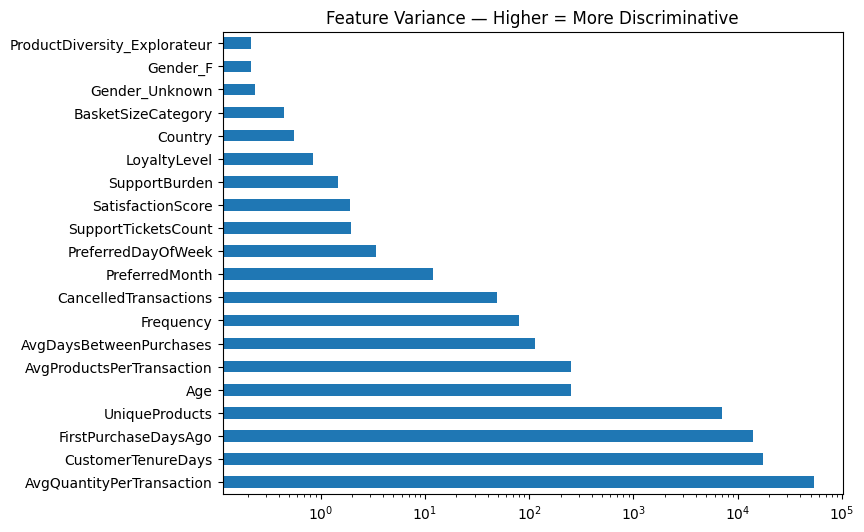

In [706]:
variance = X_train.var().sort_values(ascending=False)
print(variance.head(20))

# Visualize
variance.head(20).plot(kind='barh', figsize=(8,6),logx=True)
plt.title('Feature Variance — Higher = More Discriminative')
plt.show()

In [707]:
import numpy as np

# Must have zero NaN and zero inf before scaling
print("=== PRE-SCALING CHECKS ===")
print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"NaN in X_train: {X_train.isnull().sum().sum()}")
print(f"NaN in X_test : {X_test.isnull().sum().sum()}")
print(f"Inf in X_train: {np.isinf(X_train.select_dtypes(include=np.number)).sum().sum()}")

# Must have no object columns left
remaining_obj = X_train.select_dtypes(include='object').columns.tolist()
print(f"Object columns: {remaining_obj}")  # should be []

=== PRE-SCALING CHECKS ===
X_train shape : (3497, 39)
X_test  shape : (875, 39)
NaN in X_train: 0
NaN in X_test : 0
Inf in X_train: 0
Object columns: []


In [708]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler_final = StandardScaler()

# Fit on X_train ONLY → transform both
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled  = scaler_final.transform(X_test)

# Keep as DataFrame for readability
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("✅ Scaling done")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled  shape: {X_test_scaled.shape}")

✅ Scaling done
X_train_scaled shape: (3497, 39)
X_test_scaled  shape: (875, 39)


In [709]:
# Each feature should have mean≈0 and std≈1 on train
print("=== SCALING VERIFICATION (X_train) ===")
stats = pd.DataFrame({
    'Mean' : X_train_scaled.mean().round(6),
    'Std'  : X_train_scaled.std().round(4),
    'Min'  : X_train_scaled.min().round(4),
    'Max'  : X_train_scaled.max().round(4)
})
print(stats)

# Quick check — mean should be ~0, std should be ~1
print(f"\nMean range: {X_train_scaled.mean().min():.6f} "
      f"to {X_train_scaled.mean().max():.6f}")
print(f"Std  range: {X_train_scaled.std().min():.4f} "
      f"to {X_train_scaled.std().max():.4f}")

=== SCALING VERIFICATION (X_train) ===
                              Mean     Std     Min      Max
Frequency                     -0.0  1.0001 -0.4447  27.1094
AvgQuantityPerTransaction      0.0  1.0001 -0.7143  53.6805
CustomerTenureDays             0.0  1.0001 -0.9963   1.8149
FirstPurchaseDaysAgo           0.0  1.0001 -1.8937   1.2674
PreferredDayOfWeek             0.0  1.0001 -1.3635   1.8853
PreferredMonth                 0.0  1.0001 -1.8976   1.2754
WeekendPurchaseRatio          -0.0  1.0001 -0.4687   3.1236
AvgDaysBetweenPurchases       -0.0  1.0001 -0.3080  26.2578
UniqueProducts                -0.0  1.0001 -0.7028  20.6312
AvgProductsPerTransaction     -0.0  1.0001 -1.0368  12.7644
ZeroPriceCount                 0.0  1.0001 -0.0736  29.3452
CancelledTransactions          0.0  1.0001 -0.2809  32.0742
ReturnRatio                   -0.0  1.0001 -0.2988   8.9915
Age                            0.0  1.0001 -1.9873   1.9118
SupportTicketsCount            0.0  1.0001 -1.4141   5.0492
S

In [710]:
import joblib
import os

os.makedirs(
    r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear",
    exist_ok=True
)

# Save scaler
joblib.dump(
    scaler_final,
    r"C:\Users\LENOVO\Desktop\project_ml_retail\models\linear\scaler_final.pkl"
)

# Save scaled splits
X_train_scaled.to_csv(
    r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_train_scaled.csv",
    index=False
)
X_test_scaled.to_csv(
    r"C:\Users\LENOVO\Desktop\project_ml_retail\data\train_test\others\X_test_scaled.csv",
    index=False
)

print("✅ Scaler saved")
print("✅ Scaled splits saved")

✅ Scaler saved
✅ Scaled splits saved


## PCA

Input shape: (3497, 39)
Features: ['Frequency', 'AvgQuantityPerTransaction', 'CustomerTenureDays', 'FirstPurchaseDaysAgo', 'PreferredDayOfWeek', 'PreferredMonth', 'WeekendPurchaseRatio', 'AvgDaysBetweenPurchases', 'UniqueProducts', 'AvgProductsPerTransaction', 'ZeroPriceCount', 'CancelledTransactions', 'ReturnRatio', 'Age', 'SupportTicketsCount', 'SatisfactionScore', 'LoyaltyLevel', 'BasketSizeCategory', 'Country', 'ZeroPriceRatio', 'SupportBurden', 'Gender_F', 'Gender_M', 'Gender_Unknown', 'ProductDiversity_Explorateur', 'ProductDiversity_Modéré', 'ProductDiversity_Spécialisé', 'Region_Afrique', 'Region_Amérique du Nord', 'Region_Asie', 'Region_Autre', 'Region_Europe centrale', 'Region_Europe continentale', "Region_Europe de l'Est", 'Region_Europe du Nord', 'Region_Europe du Sud', 'Region_Moyen-Orient', 'Region_Océanie', 'Region_UK']


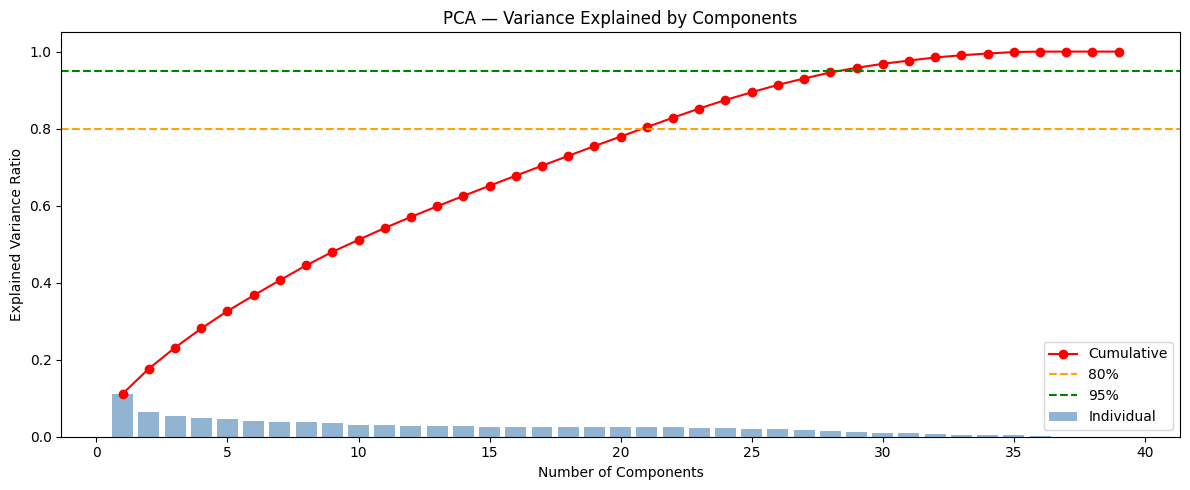

80% variance → 21 components needed
90% variance → 26 components needed
95% variance → 29 components needed


In [711]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ── Step 1: Use X_train_scaled directly ───────────────────
# You already scaled → no need to scale again
# X_train_scaled is a DataFrame with correct columns

print("Input shape:", X_train_scaled.shape)
print("Features:", X_train_scaled.columns.tolist())

# ── Step 2: Elbow curve ────────────────────────────────────
pca_full = PCA()
pca_full.fit(X_train_scaled)

explained_variance  = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(12, 5))
plt.bar(range(1, len(explained_variance) + 1),
        explained_variance, alpha=0.6,
        color='steelblue', label='Individual')
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance, 'ro-', label='Cumulative')
plt.axhline(y=0.80, color='orange', linestyle='--', label='80%')
plt.axhline(y=0.95, color='green',  linestyle='--', label='95%')
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.title('PCA — Variance Explained by Components')
plt.legend()
plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{threshold*100:.0f}% variance → {n} components needed")

⚠️ Translation in simple terms:
Information is spread across many features
Features are not strongly correlated
PCA won’t compress much without losing information

In [712]:
# ── Step 3: 2D PCA ─────────────────────────────────────────
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

print(f"PC1 explains : {pca_2d.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 explains : {pca_2d.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total        : {sum(pca_2d.explained_variance_ratio_)*100:.1f}%")

# Build PCA dataframe — use y_train for coloring target
pca_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
})

# Add back original columns for coloring
# (use original df aligned to X_train index)
pca_df['MonetaryAvg']      = y_train.values
pca_df['BasketSize']       = df.loc[X_train.index, 'BasketSizeCategory'].values
pca_df['ProductDiversity'] = df.loc[X_train.index, 'ProductDiversity'].values
pca_df['Gender']           = df.loc[X_train.index, 'Gender'].values
pca_df['Region']           = df.loc[X_train.index, 'Region'].values

PC1 explains : 11.1%
PC2 explains : 6.5%
Total        : 17.7%


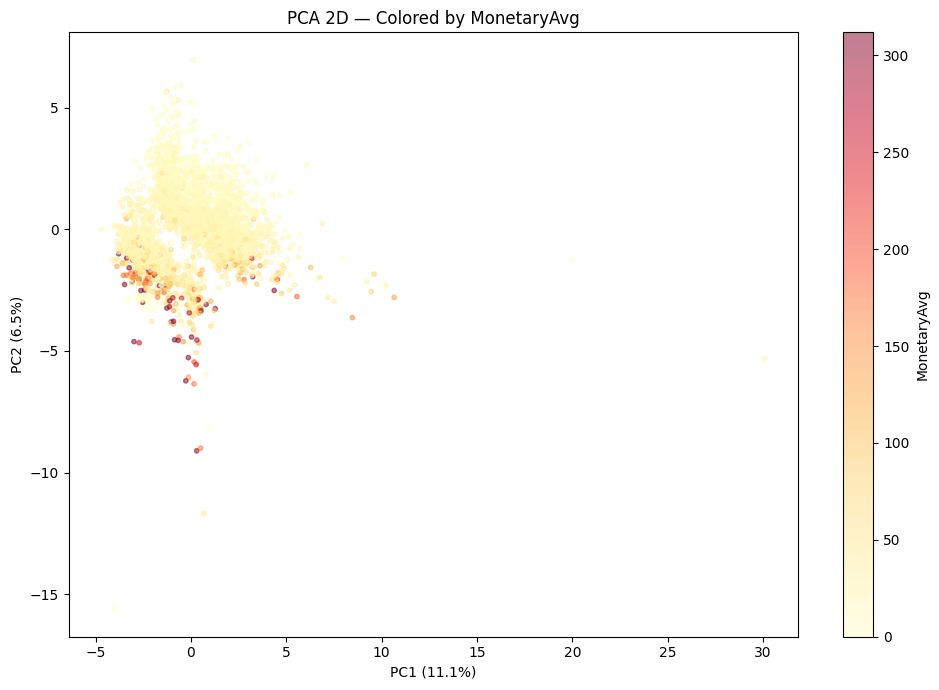

In [713]:
# ── Plot 1: Colored by MonetaryAvg (target) ────────────────
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_df['PC1'], pca_df['PC2'],
    c=pca_df['MonetaryAvg'],
    cmap='YlOrRd', alpha=0.5, s=10
)
plt.colorbar(scatter, label='MonetaryAvg')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA 2D — Colored by MonetaryAvg')
plt.tight_layout()
plt.show()

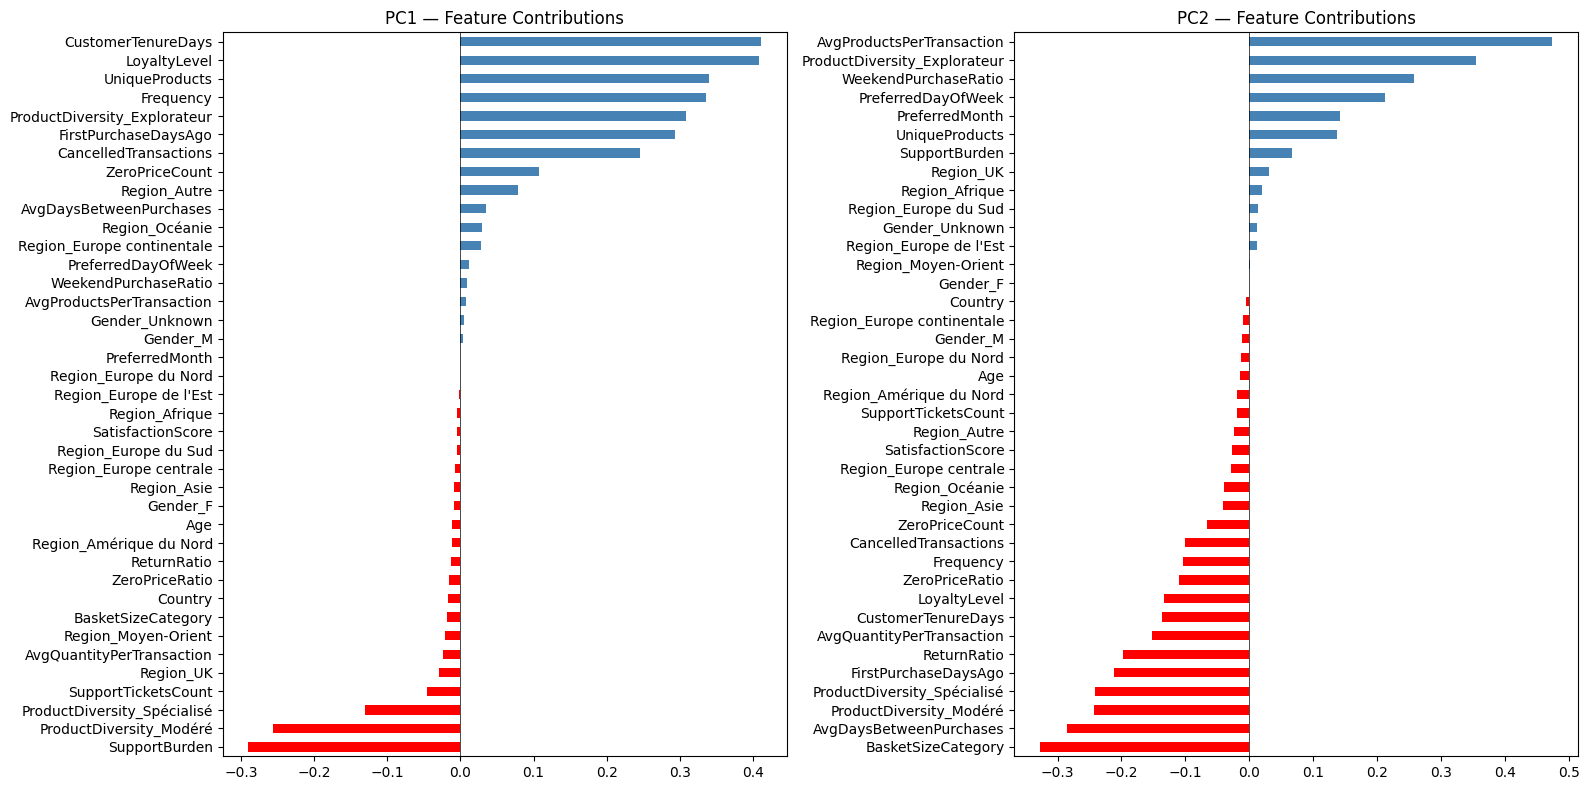

=== TOP 5 FEATURES DRIVING PC1 ===
CustomerTenureDays              0.411011
LoyaltyLevel                    0.408543
UniqueProducts                  0.340614
Frequency                       0.336056
ProductDiversity_Explorateur    0.308167
Name: PC1, dtype: float64

=== TOP 5 FEATURES DRIVING PC2 ===
AvgProductsPerTransaction       0.473965
ProductDiversity_Explorateur    0.354066
BasketSizeCategory              0.327763
AvgDaysBetweenPurchases         0.284600
WeekendPurchaseRatio            0.257709
Name: PC2, dtype: float64


In [714]:
# ── Step 5: Feature Loadings ───────────────────────────────
# Which original features drive PC1 and PC2?
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=['PC1', 'PC2'],
    index=X_train_scaled.columns  # your actual column names
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for i, pc in enumerate(['PC1', 'PC2']):
    sorted_loadings = loadings[pc].sort_values()
    colors = ['red' if x < 0 else 'steelblue'
              for x in sorted_loadings]
    sorted_loadings.plot(
        kind='barh', ax=axes[i], color=colors
    )
    axes[i].set_title(f'{pc} — Feature Contributions')
    axes[i].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Print top contributors per component
print("=== TOP 5 FEATURES DRIVING PC1 ===")
print(loadings['PC1'].abs().sort_values(ascending=False).head(5))
print("\n=== TOP 5 FEATURES DRIVING PC2 ===")
print(loadings['PC2'].abs().sort_values(ascending=False).head(5))